In [2]:
from keras.models import Sequential
from keras.layers import Dense, Input, Conv2D, MaxPool2D, Flatten, Dropout
from keras.utils import plot_model, to_categorical
from keras.datasets import cifar10
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [3]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()


170498071/170498071 [==============================] - 20s 0us/step


In [4]:

x_train.shape
# Output: (50000, 32, 32, 3)


(50000, 32, 32, 3)

In [5]:

x_test.shape
# Output: (10000, 32, 32, 3)

(10000, 32, 32, 3)

In [6]:
labels=['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

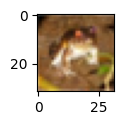

In [9]:
plt.figure(figsize=(1,1))
plt.imshow(x_train[0])

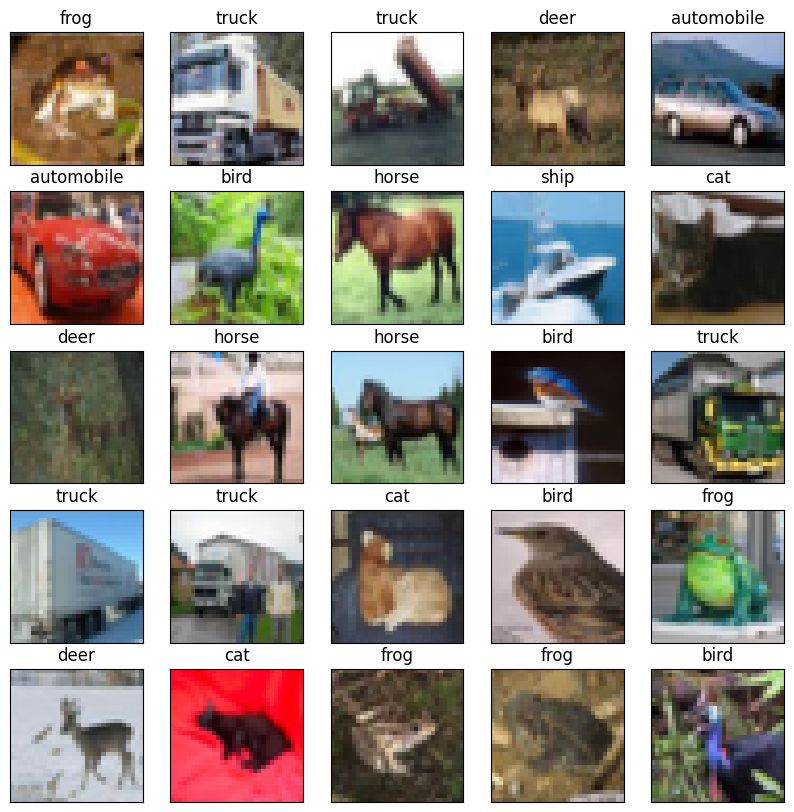

In [16]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(x_train[i])
    plt.title(labels[y_train[i][0]])
    plt.xticks([]); plt.yticks([]);

### built the model

In [17]:
model = Sequential()

model.add(Input(shape=(32, 32, 3)))

model.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(0.2))

model.add(Conv2D(filters=16, kernel_size=(3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))

model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dense(128, activation='relu'))

model.add(Dense(10, activation='softmax'))

In [18]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 30, 30, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 15, 15, 32)        0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 15, 15, 32)        0         
                                                                 
 conv2d_1 (Conv2D)           (None, 13, 13, 16)        4624      
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 6, 6, 16)          0         
 g2D)                                                            
                                                                 
 flatten (Flatten)           (None, 576)               0

In [23]:
model.compile(
    loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"]
)

In [24]:
model.fit(x_train, y_train, epochs=10, batch_size=10)

Epoch 1/10
5000/5000 [==============================] - 62s 12ms/step - loss: 2.1127 - accuracy: 0.2553
Epoch 2/10
5000/5000 [==============================] - 60s 12ms/step - loss: 1.5167 - accuracy: 0.4566
Epoch 3/10
5000/5000 [==============================] - 60s 12ms/step - loss: 1.3786 - accuracy: 0.5151
Epoch 4/10
5000/5000 [==============================] - 60s 12ms/step - loss: 1.2836 - accuracy: 0.5536
Epoch 5/10
5000/5000 [==============================] - 60s 12ms/step - loss: 1.2219 - accuracy: 0.5783
Epoch 6/10
5000/5000 [==============================] - 59s 12ms/step - loss: 1.1711 - accuracy: 0.5974
Epoch 7/10
5000/5000 [==============================] - 60s 12ms/step - loss: 1.1189 - accuracy: 0.6168
Epoch 8/10
5000/5000 [==============================] - 60s 12ms/step - loss: 1.0866 - accuracy: 0.6323
Epoch 9/10
5000/5000 [==============================] - 60s 12ms/step - loss: 1.0506 - accuracy: 0.6456
Epoch 10/10
5000/5000 [==============================] - 60s 12m

###  prediction new data

In [29]:
import cv2

In [46]:
new = cv2.imread("C:/Users/PGCP-AI/Desktop/NLP&CV/DATASETS/images/horse.jpg")

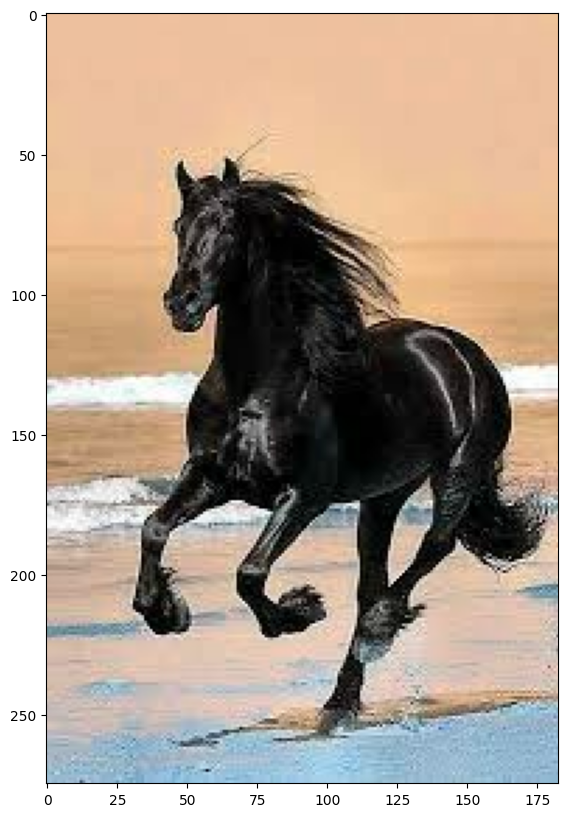

In [47]:
plt.figure(figsize=(10,10))
plt.imshow(new)

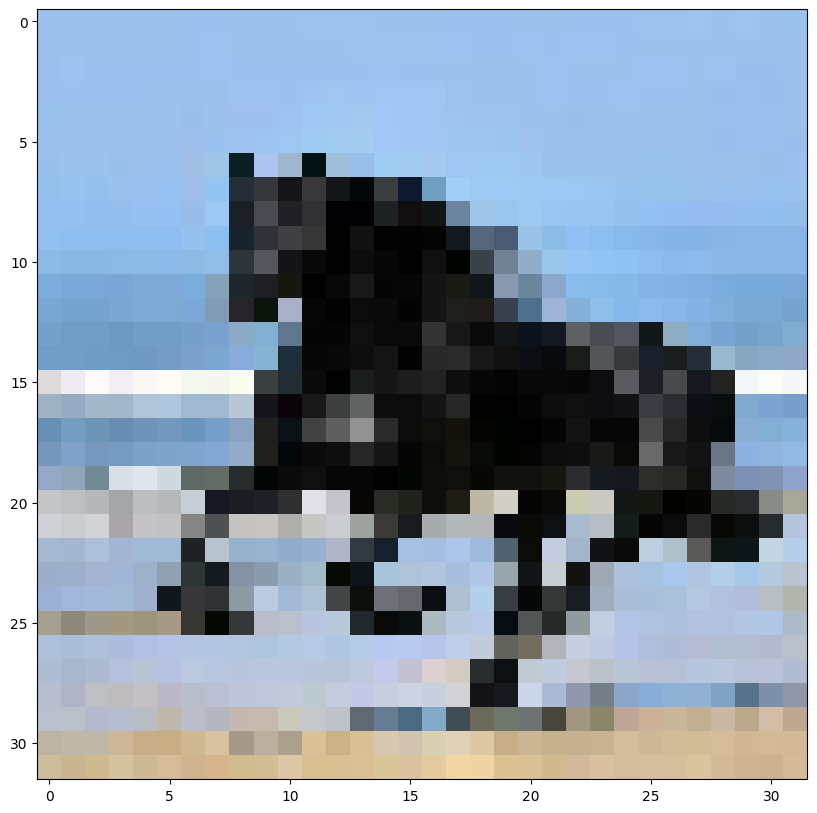

In [48]:
new = cv2.cvtColor(new, cv2.COLOR_BGR2RGB)
new = cv2.resize(new, (32, 32))
plt.figure(figsize=(10,10))
plt.imshow(new)